### Домашнее задание 11

**Задача 1**

Получите с помощью символьной алгебры уравнения движения двойного маятника с одинаковыми длинами сегментов и массами. Просимулируйте поведение этой системы.


(0.25*g*sin(alpha(t) - 2*beta(t)) + 0.75*g*sin(alpha(t)) + 0.5*l*sin(alpha(t) - beta(t))*Derivative(beta(t), t)**2 + 0.25*l*sin(2*alpha(t) - 2*beta(t))*Derivative(alpha(t), t)**2)/(l*(0.25*cos(2*alpha(t) - 2*beta(t)) - 0.75))

(-0.5*g*sin(2*alpha(t) - beta(t)) + 0.5*g*sin(beta(t)) - 1.0*l*sin(alpha(t) - beta(t))*Derivative(alpha(t), t)**2 - 0.25*l*sin(2*alpha(t) - 2*beta(t))*Derivative(beta(t), t)**2)/(l*(0.25*cos(2*alpha(t) - 2*beta(t)) - 0.75))

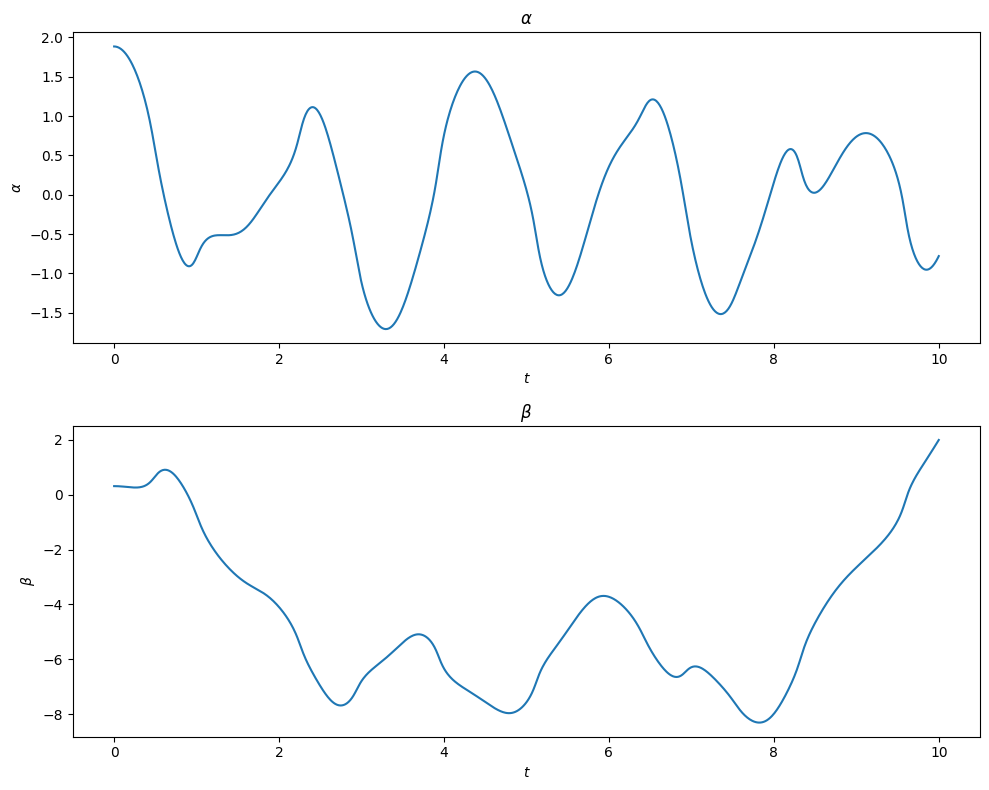

This browser does not support the video tag.


In [ ]:
from functools import partial

import numpy as np
import sympy as sp
import cv2
import mediapy as mp
from scipy.integrate import odeint
from IPython.display import display
from matplotlib import pyplot as plt

t, g, l, m = sp.symbols("t g l m")

alpha = sp.symbols("alpha", cls=sp.Function)(t)
beta = sp.symbols("beta", cls=sp.Function)(t)

alpha_dt = sp.diff(alpha, t)
beta_dt = sp.diff(beta, t)

alpha_ddt = sp.diff(alpha_dt, t)
beta_ddt = sp.diff(beta_dt, t)

x1 = l * sp.sin(alpha)
y1 = -l * sp.cos(alpha)

x2 = x1 + l * sp.sin(beta)
y2 = y1 - l * sp.cos(beta)

x1_dt = sp.diff(x1, t)
y1_dt = sp.diff(y1, t)

x2_dt = sp.diff(x2, t)
y2_dt = sp.diff(y2, t)

energy_kinetic = 0.5 * m * (x1_dt**2 + y1_dt**2 + x2_dt**2 + y2_dt**2)
energy_potential = m * g * (y1 + y2)

lagrangian = energy_kinetic - energy_potential

el1 = sp.diff(lagrangian, alpha) - sp.diff(lagrangian, alpha_dt, t)
el2 = sp.diff(lagrangian, beta) - sp.diff(lagrangian, beta_dt, t)

ddts = sp.solve([el1, el2], [alpha_ddt, beta_ddt])

display(ddts[alpha_ddt].simplify())
display(ddts[beta_ddt].simplify())

alpha_dt_fn = sp.lambdify((alpha_dt), alpha_dt)
beta_dt_fn = sp.lambdify((beta_dt), beta_dt)

alpha_ddt_fn = sp.lambdify((alpha, beta, alpha_dt, beta_dt, g, l, m), ddts[alpha_ddt])
beta_ddt_fn = sp.lambdify((alpha, beta, alpha_dt, beta_dt, g, l, m), ddts[beta_ddt])


def xdot(x: np.ndarray, t: float, g: float, l: float, m: float) -> np.ndarray:
    return [
        alpha_dt_fn(x[2]),
        beta_dt_fn(x[3]),
        alpha_ddt_fn(x[0], x[1], x[2], x[3], g, l, m),
        beta_ddt_fn(x[0], x[1], x[2], x[3], g, l, m),
    ]


t = np.linspace(0, 10, 1000)
x0 = np.array([np.pi * 0.6, np.pi * 0.1, 0, 0], dtype=np.float32)
traj = odeint(partial(xdot, g=9.81, l=1, m=1), x0, t)

alpha_traj = traj[:, 0]
beta_traj = traj[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(t, alpha_traj)
axes[0].set_title(r"$\alpha$")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\alpha$")

axes[1].plot(t, beta_traj)
axes[1].set_title(r"$\beta$")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$\beta$")

plt.tight_layout()
plt.show()


def visualize(traj: np.ndarray, l: float, frame_skip: int = 10) -> np.ndarray:
    frames = []
    h, w = 400, 400
    cx, cy = w // 2, h // 2  
    margin = 10
    if l <= 0:
        scale = 0.0
    else:
        max_reach = 2.0 * float(l)
        scale = min((w / 2 - margin) / max_reach, (h / 2 - margin) / max_reach)

    for i in range(0, len(traj), frame_skip):
        canvas = np.zeros((h, w, 3), dtype=np.uint8)

        a = float(traj[i, 0])
        b = float(traj[i, 1])

        x1 = l * np.sin(a)
        y1 = l * np.cos(a)
        x2 = x1 + l * np.sin(b)
        y2 = y1 + l * np.cos(b)

        p0 = (int(cx), int(cy))
        p1 = (int(cx + scale * x1), int(cy + scale * y1))
        p2 = (int(cx + scale * x2), int(cy + scale * y2))

        cv2.line(canvas, p0, p1, (220, 220, 220), 2, lineType=cv2.LINE_AA)
        cv2.line(canvas, p1, p2, (220, 220, 220), 2, lineType=cv2.LINE_AA)

        cv2.circle(canvas, p0, 4, (255, 255, 255), -1, lineType=cv2.LINE_AA)
        cv2.circle(canvas, p1, 6, (0, 200, 0), -1, lineType=cv2.LINE_AA)
        cv2.circle(canvas, p2, 8, (0, 0, 255), -1, lineType=cv2.LINE_AA)

        cv2.rectangle(canvas, (5, 5), (w - 6, h - 6), (60, 60, 60), 1)

        frames.append(canvas)

    return np.stack(frames)

frames = visualize(traj, l=1)

mp.show_video(frames, fps=10)


**Задача 2**

Получите с помощью символьной алгебры уравнения движения Cart-pole. Просимулируйте поведение этой системы.


m_2*(-g*cos(alpha(t)) + l*Derivative(alpha(t), t)**2)*sin(alpha(t))/(m_1 + m_2*sin(alpha(t))**2)

(g*m_1 + g*m_2 - l*m_2*cos(alpha(t))*Derivative(alpha(t), t)**2)*sin(alpha(t))/(l*(m_1 + m_2*sin(alpha(t))**2))

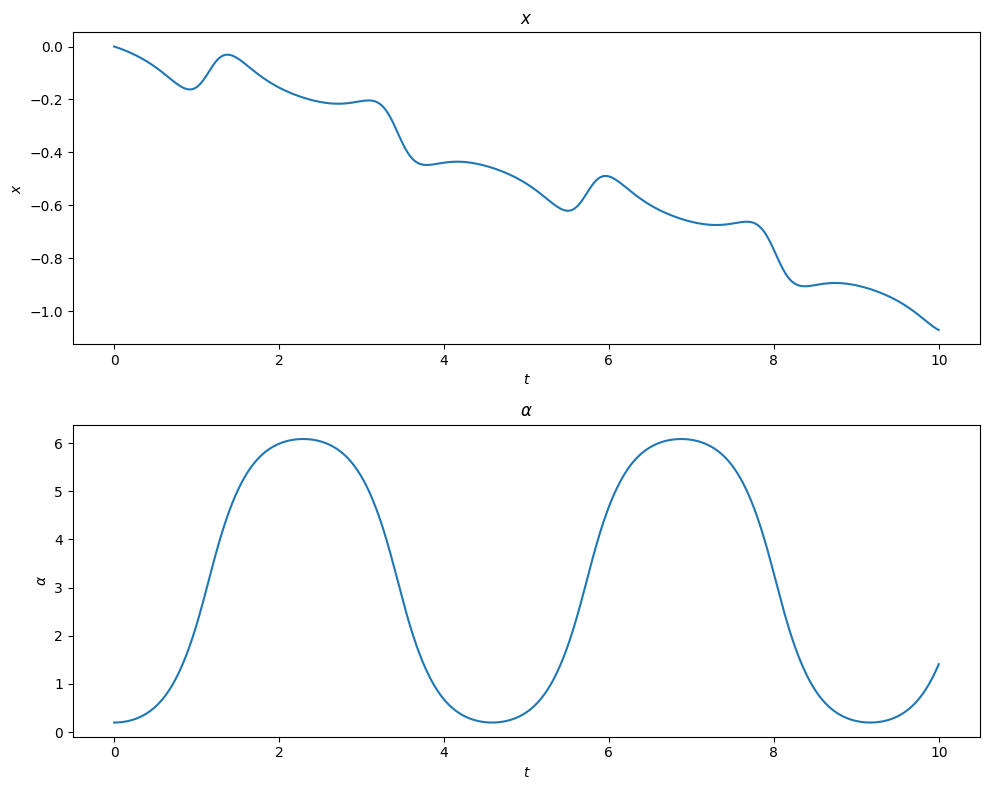

This browser does not support the video tag.


In [86]:
t, g, m1, m2, l = sp.symbols("t g m_1 m_2 l")

x = sp.symbols("x", cls=sp.Function)(t)
alpha = sp.symbols("alpha", cls=sp.Function)(t)

x_dt = sp.diff(x, t)
alpha_dt = sp.diff(alpha, t)

x_ddt = sp.diff(x_dt, t)
alpha_ddt = sp.diff(alpha_dt, t)

x_pole = x + l * sp.sin(alpha)
y_pole = l * sp.cos(alpha)

x_pole_dt = sp.diff(x_pole, t)
y_pole_dt = sp.diff(y_pole, t)

energy_kinetic = 0.5 * (m1 * x_dt**2 + m2 * (x_pole_dt**2 + y_pole_dt**2))
energy_potential = m2 * g * y_pole

lagrangian = energy_kinetic - energy_potential

el1 = sp.diff(lagrangian, x) - sp.diff(lagrangian, x_dt, t)
el2 = sp.diff(lagrangian, alpha) - sp.diff(lagrangian, alpha_dt, t)

ddts = sp.solve([el1, el2], [x_ddt, alpha_ddt])

display(ddts[x_ddt].simplify())
display(ddts[alpha_ddt].simplify())

x_dt_fn = sp.lambdify((x_dt), x_dt)
alpha_dt_fn = sp.lambdify((alpha_dt), alpha_dt)

x_ddt_fn = sp.lambdify((x, alpha, x_dt, alpha_dt, g, l, m1, m2), ddts[x_ddt])
alpha_ddt_fn = sp.lambdify((x, alpha, x_dt, alpha_dt, g, l, m1, m2), ddts[alpha_ddt])


def xdot(x: np.ndarray, t: float, g: float, l: float, m1: float, m2: float) -> np.ndarray:
    return [
        x_dt_fn(x[2]),
        alpha_dt_fn(x[3]),
        x_ddt_fn(x[0], x[1], x[2], x[3], g, l, m1, m2),
        alpha_ddt_fn(x[0], x[1], x[2], x[3], g, l, m1, m2),
    ]

t = np.linspace(0, 10, 1000)
x0 = np.array([0, 0.2, -0.1, 0], dtype=np.float32)
traj = odeint(partial(xdot, g=9.81, l=1, m1=10, m2=1), x0, t)

x_traj = traj[:, 0]
alpha_traj = traj[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(t, x_traj)
axes[0].set_title(r"$x$")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$x$")

axes[1].plot(t, alpha_traj)
axes[1].set_title(r"$\alpha$")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$\alpha$")

plt.tight_layout()
plt.show()

def visualize(traj: np.ndarray, l: float, frame_skip: int = 10) -> np.ndarray:
    frames = []
    h, w = 400, 800
    cx, cy = w // 2, h // 2  
    margin = 10
    
    if l <= 0:
        scale = 0.0
    else:
        reach = float(l)
        scale = (h / 2 - margin) / reach
    
    cart_w = 0.2 * l * scale
    cart_h = 0.1 * l * scale
    
    for i in range(0, len(traj), frame_skip):
        canvas = np.zeros((h, w, 3), dtype=np.uint8)

        x = float(traj[i, 0]) * scale + cx
        alpha = float(traj[i, 1])
        
        cv2.circle(canvas, (int(x), int(cy)), 4, (255, 255, 255), -1, lineType=cv2.LINE_AA)
        cv2.rectangle(canvas, (int(x - cart_w / 2), int(cy - cart_h / 2)), (int(x + cart_w / 2), int(cy + cart_h / 2)), (20, 220, 20), 2, lineType=cv2.LINE_AA)

        pole_tip_x = x + l * scale * np.sin(alpha)
        pole_tip_y = cy - l * scale * np.cos(alpha)

        cv2.line(canvas, (int(x), int(cy)), (int(pole_tip_x), int(pole_tip_y)), (20, 220, 20), 2, lineType=cv2.LINE_AA)
        cv2.circle(canvas, (int(pole_tip_x), int(pole_tip_y)), 4, (255, 255, 255), -1, lineType=cv2.LINE_AA)

        frames.append(canvas)

    return np.stack(frames)

frames = visualize(traj, l=1)

mp.show_video(frames, fps=10)


**Задача 3**

Рассмотрим систему, состоящую из массивной бусины на проволоке, изогнутой в форме параболы слева и куба справа. Система находится в поле тяготения, все расстояния в метрах, $\Delta t = 0.01$ с.

Получите с помощью символьной алгебры уравнения движения и просимулируйте поведение этой системы.



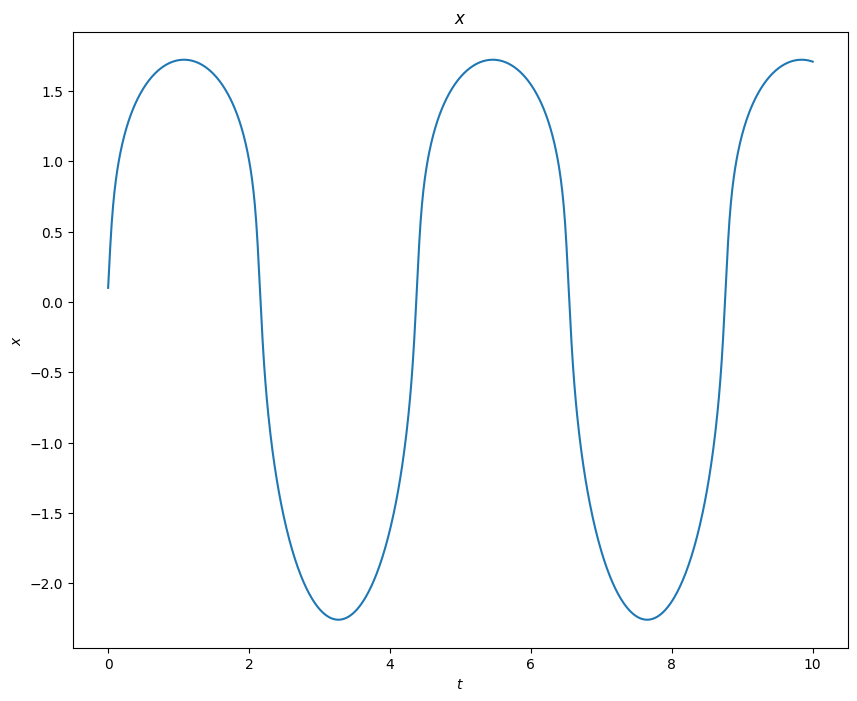

This browser does not support the video tag.


In [131]:
from typing import Callable

(
    t,
    g,
    m,
) = sp.symbols("t g m")

x = sp.symbols("x", cls=sp.Function)(t)

y = sp.simplify(sp.Piecewise((x**2, x < 0), (x**3, x >= 0)))

x_dt = sp.diff(x, t)
x_ddt = sp.diff(x_dt, t)

y_dt = sp.simplify(sp.diff(y, t))
y_ddt = sp.simplify(sp.diff(y_dt, t))

energy_kinetic = 0.5 * m * (x_dt**2 + y_dt**2)
energy_potential = m * g * y

lagrangian = energy_kinetic - energy_potential

el = sp.diff(lagrangian, x) - sp.diff(lagrangian, x_dt, t)

x_ddt_rhs = sp.solve(el, x_ddt)
x_ddt_rhs = sp.Piecewise((x_ddt_rhs[0], x >= 0), (x_ddt_rhs[1], x < 0))

x_dt_fn = sp.lambdify((x_dt), x_dt)
x_ddt_fn = sp.lambdify((x, x_dt, g, m), x_ddt_rhs)
y_fn = sp.lambdify((x), y)


def xdot(x: np.ndarray, t: float, g: float, m: float) -> np.ndarray:
    return [
        x_dt_fn(x[1]),
        x_ddt_fn(x[0], x[1], g, m),
    ]


x0 = np.array([0.1, 10], dtype=np.float32)
horizon = 10
t = np.linspace(0, horizon, int(horizon / 0.01))
traj = odeint(partial(xdot, g=9.81, m=1), x0, t)


fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.plot(t, traj[:, 0])
ax.set_title(r"$x$")
ax.set_xlabel("$t$")
ax.set_ylabel(r"$x$")

plt.show()


def visualize(traj: np.ndarray, y_fn: Callable, frame_skip: int = 10) -> np.ndarray:
    frames = []
    h, w = 400, 400
    cx, cy = w // 2, 370
    scale = cy / 7.0

    x_min = (0 - cx) / scale
    x_max = (w - cx) / scale

    xs_wire = np.linspace(x_min, x_max, 800)
    ys_wire = np.asarray(y_fn(xs_wire), dtype=float)

    def to_px(x, y):
        px = int(cx + x * scale)
        py = int(cy - y * scale)
        return px, py

    pts = []
    for xv, yv in zip(xs_wire, ys_wire):
        px, py = to_px(xv, yv)
        pts.append([px, py])
    poly = np.array(pts, dtype=np.int32).reshape((-1, 1, 2))

    for i in range(0, len(traj), frame_skip):
        canvas = np.zeros((h, w, 3), dtype=np.uint8)

        cv2.polylines(canvas, [poly], isClosed=False, color=(0, 0, 255), thickness=2, lineType=cv2.LINE_AA)

        x = float(traj[i, 0])
        y = float(y_fn(x))
        bx, by = to_px(x, y)
        cv2.circle(canvas, (bx, by), 6, (255, 0, 0), -1, lineType=cv2.LINE_AA)

        frames.append(canvas)

    return np.stack(frames)


frames = visualize(traj, y_fn)

mp.show_video(frames, fps=10)